# NBA Salary Prediction — Exploratory Data Analysis

Goal: Understand what drives NBA player salaries through visualization.
Each chart answers a specific business question.

Salary is cleaned to numeric here for visualization purposes.
Full preprocessing pipeline handled in 03_preprocessing.ipynb.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [5]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Load datasets

In [6]:
DATA_DIR = Path('../data')

player_season_stats = pd.read_csv(DATA_DIR / '24-25_season_stats_per_100_possesions.csv')
player_salary = pd.read_csv(DATA_DIR / '25-26_nba_salary_contracts.csv')

## Change Salaries from string to float

In [7]:
player_salary['salary'] = player_salary['2025-26']\
    .astype(str)\
    .str.replace('$', '', regex=False)\
    .str.replace(',', '', regex=False)\
    .replace('nan', np.nan)\
    .astype(float)

cols_to_drop = ['2025-26', '2026-27', '2027-28', '2028-29', '2029-30', '2030-31', 'Guaranteed', 'Rk']
player_salary = player_salary.drop(columns=cols_to_drop)

print("Salary dataframe cleaned:")
print(player_salary.head(5).to_string())
print(f"\nColumns remaining: {player_salary.columns.tolist()}")
print(f"Dtype: {player_salary['salary'].dtype}")

Salary dataframe cleaned:
          Player   Tm  Player_ID      salary
0  Stephen Curry  GSW  curryst01  59606817.0
1    Joel Embiid  PHI  embiijo01  55224526.0
2   Nikola Jokić  DEN  jokicni01  55224526.0
3   Kevin Durant  HOU  duranke01  54708609.0
4   Jayson Tatum  BOS  tatumja01  54126450.0

Columns remaining: ['Player', 'Tm', 'Player_ID', 'salary']
Dtype: float64


## Salary deduplication


Duplicates occurred because traded players appear once per team 
in the salary data. For example Damian Lillard appears for both 
MIL and POR with the same $36.6M salary — the contract travels 
with the player regardless of team.

Since salary is identical across all duplicate rows for the same 
player, we simply keep the first occurrence. No salary information 
is lost.

In [8]:
player_salary = player_salary.drop_duplicates(subset='Player_ID', keep='first')

print(f"Rows after dedup: {len(player_salary)}")
print(f"Unique players: {player_salary['Player_ID'].nunique()}")

Rows after dedup: 488
Unique players: 488


## Handle traded players — keep combined row only

In [9]:
traded_ids = player_season_stats[
    player_season_stats.duplicated('Player-ID', keep=False)
]['Player-ID'].unique()

traded_rows     = player_season_stats[
    (player_season_stats['Player-ID'].isin(traded_ids)) &
    (player_season_stats['Team'].isin(['2TM', '3TM']))
]
non_traded_rows = player_season_stats[
    ~player_season_stats['Player-ID'].isin(traded_ids)
]
player_season_stats= pd.concat([non_traded_rows, traded_rows]).reset_index(drop=True)

print(f"Stats after dedup: {player_season_stats.shape[0]} rows")
print(f"Traded players kept as combined row: {len(traded_ids)}")

Stats after dedup: 569 rows
Traded players kept as combined row: 81


## Handle traded players in stats
Players traded mid-season appear multiple times in Basketball Reference.
2TM = traded once, 3TM = traded twice.
These combined rows represent full season totals — exactly what we want
for modeling since we care about full season performance not team splits.

## Merge datasets on Player-ID

In [10]:
df = player_season_stats.merge(
    player_salary[['Player_ID', 'salary']],
    left_on='Player-ID',
    right_on='Player_ID',
    how='inner'
).drop(columns=['Player_ID'])

print(f"Players after merge: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nSalary range:")
print(f"  Min:    ${df['salary'].min():>12,.0f}")
print(f"  Median: ${df['salary'].median():>12,.0f}")
print(f"  Mean:   ${df['salary'].mean():>12,.0f}")
print(f"  Max:    ${df['salary'].max():>12,.0f}")

Players after merge: 424
Columns: 35

Salary range:
  Min:    $      70,732
  Median: $   6,670,882
  Mean:   $  12,724,594
  Max:    $  59,606,817


## Merge stats and salary

424 players with both 2024-25 performance stats and 2025-26 contracts.

Salary range:
- Min:    $70,732 — minimum wage / two-way contracts
- Median: $6.7M — typical rotation player  
- Mean:   $12.7M — pulled up by max contracts
- Max:    $59.6M — Stephen Curry

The gap between median ($6.7M) and mean ($12.7M) confirms right skew —
a small number of max contract players pull the average significantly 
higher. We will log-transform salary before modeling to normalize 
this distribution.

## Visual 1: Salary distribution
Business question: How are NBA salaries distributed across the league?

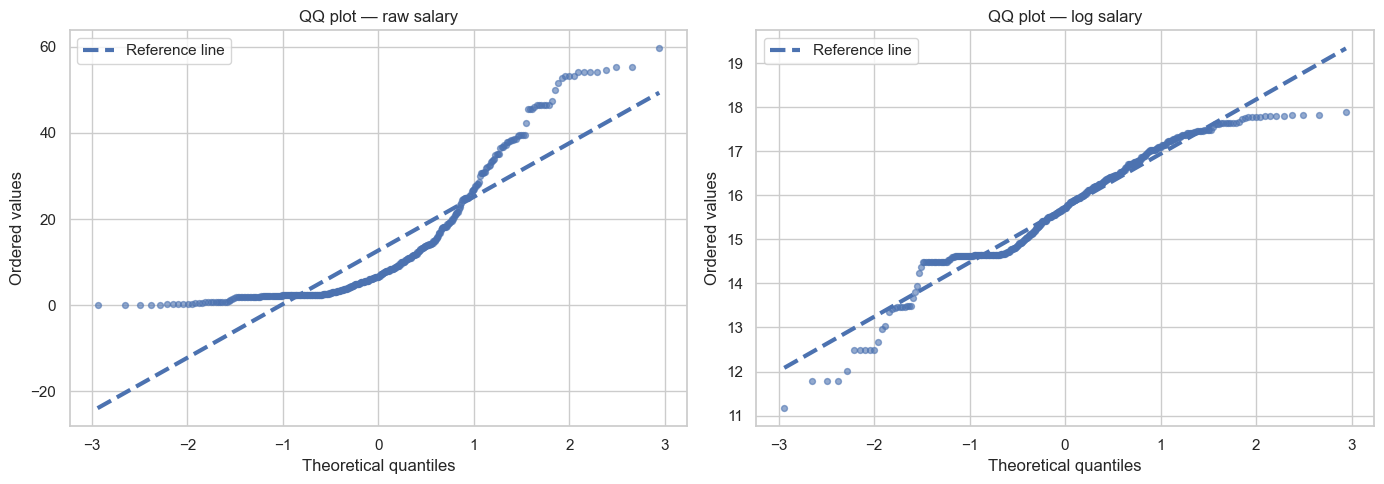

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def add_qq(ax, data, title):
    clean = pd.Series(data).replace([np.inf, -np.inf], np.nan).dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(clean, dist='norm')

    ax.scatter(osm, osr, s=18, alpha=0.6, zorder=1)

    x_line = np.linspace(osm.min(), osm.max(), 200)
    y_line = slope * x_line + intercept

    ax.plot(
        x_line,
        y_line,
        linewidth=3,
        linestyle='--',
        zorder=3,
        label='Reference line'
    )

    ax.set_title(title)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Ordered values')
    ax.legend()

add_qq(axes[0], df['salary'] / 1e6, 'QQ plot — raw salary')
add_qq(axes[1], np.log(df.loc[df['salary'] > 0, 'salary']), 'QQ plot — log salary')

plt.tight_layout()
plt.savefig('../outputs/01_salary_qq_plots.png')
plt.show()

## Finding — QQ plots confirm log transformation needed

Raw salary (left): Points curve dramatically above the reference line 
at the upper tail — classic right skew signature. Max contract players 
($40M-$60M) are extreme outliers pulling the distribution. The flat 
cluster near zero on the left represents minimum wage players.

Log salary (right): Points follow the reference line much more closely 
across the full range. The small stepped deviation at the lower left 
tail represents two-way contract players sitting at the NBA minimum 
wage floor — a structural feature of NBA contracts, not a data problem.
The upper tail also tightens significantly compared to raw salary.

Conclusion: Log transformation meaningfully normalizes the salary 
distribution. We will use log(salary) as the target variable in 
modeling and convert predictions back to dollars using exp() 
for interpretability.

## Visual 2: Salary by position
Business question: Which positions command the highest salaries?

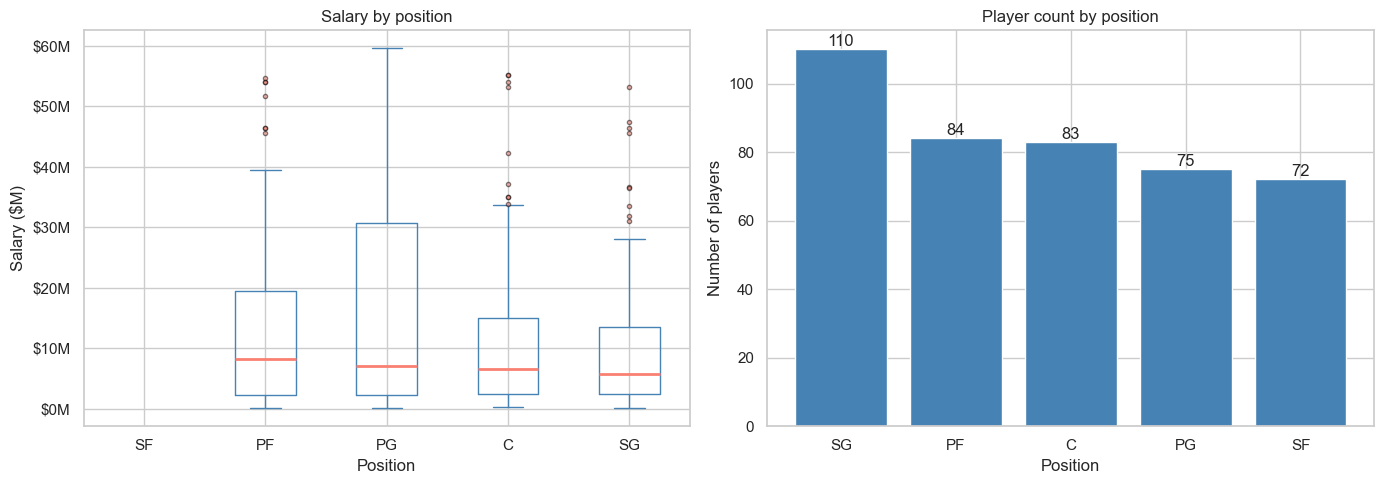

Median salary by position:
Pos
SF    $8.4M
PF    $8.2M
PG    $7.0M
C     $6.5M
SG    $5.7M

Player count by position:
Pos
SG    110
PF     84
C      83
PG     75
SF     72


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_order = df.groupby('Pos')['salary'].median()\
              .sort_values(ascending=False).index.tolist()

df_pos = [df[df['Pos'] == p]['salary'] / 1e6 for p in pos_order]
axes[0].boxplot(df_pos,
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='salmon', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                flierprops=dict(marker='o', markerfacecolor='salmon',
                                markersize=3, alpha=0.5))
axes[0].set_xticklabels(pos_order)
axes[0].set_title('Salary by position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Salary ($M)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:.0f}M'))

# Right — player count by position
pos_counts = df['Pos'].value_counts()
axes[1].bar(pos_counts.index, pos_counts.values, color='steelblue')
axes[1].set_title('Player count by position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Number of players')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/02_salary_by_position.png')
plt.show()

print("Median salary by position:")
print(df.groupby('Pos')['salary']
        .median()
        .sort_values(ascending=False)
        .apply(lambda x: f'${x/1e6:.1f}M')
        .to_string())

print("\nPlayer count by position:")
print(df['Pos'].value_counts().to_string())

## Finding
Salary distributions are surprisingly similar across all five positions.
No single position commands dramatically higher pay — the median salary 
hovers around $7-9M for all positions.

Key observations:
- PF has the highest median salary (~$9M) and widest spread
- PG shows the highest upper outliers — elite point guards (Curry, 
  Lillard) command max contracts
- C has a tighter distribution — fewer extreme outliers at the top
- SG has the most players (110) but one of the lower medians
- SF has the fewest players (72)

Business implication for the model: Position alone is a weak 
predictor of salary. Performance stats will likely matter far 
more than position — a finding we will confirm in the next visual.

## Visual 3: Stat correlations with salary
Business question: Which performance metrics are most strongly 
associated with player salary?

Columns after removing proxy variables: 33


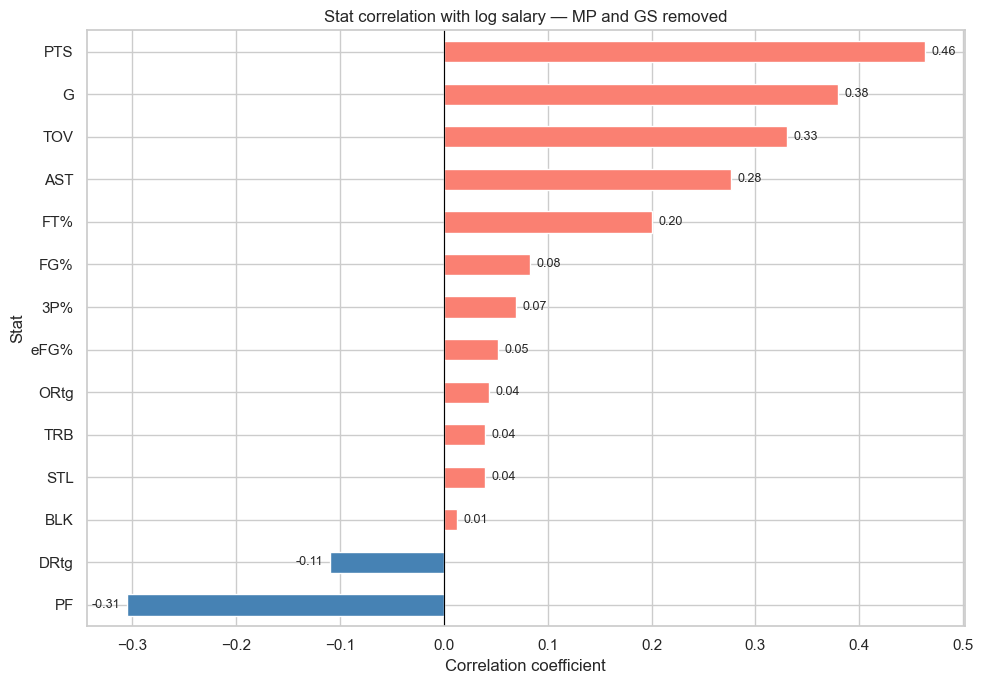

PTS     0.463
G       0.379
TOV     0.330
AST     0.276
FT%     0.200
FG%     0.083
3P%     0.069
eFG%    0.052
ORtg    0.043
TRB     0.039
STL     0.039
BLK     0.012
DRtg   -0.109
PF     -0.305
dtype: float64


In [ ]:
cols_to_exclude = ['MP', 'GS']
df = df.drop(columns=[c for c in cols_to_exclude if c in df.columns])

print(f"Columns after removing proxy variables: {df.shape[1]}")

# Select key performance stats
stat_cols = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV',
             'FG%', '3P%', 'FT%', 'ORtg', 'DRtg',
             'G', 'eFG%', 'PF']

# Correlations with log salary
log_salary = np.log(df['salary'])
correlations = df[stat_cols].corrwith(log_salary)\
                             .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['salmon' if c > 0 else 'steelblue' for c in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Stat correlation with log salary — MP and GS removed')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('Stat')

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left' if p.get_width() > 0 else 'right',
                va='center',
                xytext=(5 if p.get_width() > 0 else -5, 0),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_stat_correlations.png')
plt.show()

print(correlations.sort_values(ascending=False).round(3))

## Note: Excluding minutes played (MP)

MP is excluded from modeling due to multicollinearity.
High-usage players earn more AND play more minutes — including MP 
would create a circular relationship where the model learns 
"players who play more earn more" rather than identifying which 
performance skills drive salary.

Since we are using per 100 possession stats, playing time is 
already normalized. MP adds no independent signal beyond what 
PTS, AST, TOV and other usage stats already capture.

G (games played) is kept — durability and availability are 
genuine signals teams value when signing contracts.